##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
pip install torch torchvision scikit-learn numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


# IMPORT LIBRARIES

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# CONFIG

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_IMAGES= 20       # total images to sample
N_CLUSTERS= 2       # cats vs dogs
SEED= 42

# LOAD DINOV2 MODEL

In [4]:
print("Loading DINOv2 ViT-S/14 …")
model = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
model.eval().to(DEVICE)
print(f"  Model on: {DEVICE}")

Loading DINOv2 ViT-S/14 …
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /Users/raghadhome/.cache/torch/hub/main.zip


/Users/raghadhome/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/raghadhome/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/raghadhome/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /Users/raghadhome/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:08<00:00, 10.7MB/s]


  Model on: cpu


# TRANSFORMS

In [5]:
# DINOv2 expects ImageNet-style normalisation; ViT-S/14 patch size = 14
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# DOWNLOAD OXFORD-IIIT PETS & BUILD BALANCED SAMPLE

In [6]:
dataset = datasets.OxfordIIITPet(
    root="./data",
    split="test",          # smaller split, downloads faster
    target_types="binary-category",   # 0 = Cat, 1 = Dog
    transform=transform,
    download=True,
)

100%|██████████| 792M/792M [01:15<00:00, 10.5MB/s]  
100%|██████████| 19.2M/19.2M [00:07<00:00, 2.45MB/s]


In [10]:
cat_indices = [i for i, (_, lbl) in enumerate(dataset) if lbl == 0]
dog_indices = [i for i, (_, lbl) in enumerate(dataset) if lbl == 1]

rng = np.random.default_rng(SEED)
n_each = N_IMAGES // 2
selected_cat = rng.choice(cat_indices, size=n_each, replace=False).tolist()
selected_dog = rng.choice(dog_indices, size=n_each, replace=False).tolist()
selected_indices = selected_cat + selected_dog   # 10 cats, then 10 dogs

print(f"  Selected {n_each} cat images + {n_each} dog images = {N_IMAGES} total")

  Selected 10 cat images + 10 dog images = 20 total


# EXTRACT [CLS] TOKENS

In [11]:
print("\nExtracting 384-dim [CLS] tokens via DINOv2 …")

cls_tokens    = []
ground_truths = []   # 0 = Cat, 1 = Dog

with torch.no_grad():
    for idx in selected_indices:
        img_tensor, label = dataset[idx]
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)   # (1, 3, 224, 224)

        # forward_features returns the patch + CLS token embeddings
        features = model.forward_features(img_tensor)
        cls = features["x_norm_clstoken"]                 # shape (1, 384)

        cls_tokens.append(cls.squeeze(0).cpu().numpy())
        ground_truths.append(label)

cls_tokens    = np.array(cls_tokens)       # (20, 384)
ground_truths = np.array(ground_truths)    # (20,)  0=Cat, 1=Dog

print(f"  CLS token matrix shape : {cls_tokens.shape}")
print(f"  Ground-truth labels    : {ground_truths.tolist()}")


Extracting 384-dim [CLS] tokens via DINOv2 …
  CLS token matrix shape : (20, 384)
  Ground-truth labels    : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


# K-MEANS CLUSTERING


In [12]:

print("\nRunning KMeans (n_clusters=2) …")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init="auto")
cluster_labels = kmeans.fit_predict(cls_tokens)   # 0 or 1 for each image
print(f"  Raw cluster labels: {cluster_labels.tolist()}")


Running KMeans (n_clusters=2) …
  Raw cluster labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


# ALIGN CLUSTER IDs TO CAT/DOG CONVENTION

In [13]:
# KMeans cluster IDs are arbitrary; match them to ground truth by majority vote
def align_clusters(pred, true, n_clusters=2):
    """Return relabelled predictions aligned to ground-truth convention."""
    aligned = pred.copy()
    for cluster_id in range(n_clusters):
        mask = pred == cluster_id
        if mask.sum() == 0:
            continue
        # majority class in this cluster
        majority = int(np.round(true[mask].mean()))
        aligned[mask] = majority
    return aligned

aligned_labels = align_clusters(cluster_labels, ground_truths)
accuracy = accuracy_score(ground_truths, aligned_labels)

# RESULTS

In [14]:
CLASS_NAMES = {0: "Cat", 1: "Dog"}

print("\n" + "=" * 50)
print("RESULTS")
print("=" * 50)
print(f"{'Image':>5}  {'True Label':>10}  {'Cluster':>7}  {'Match':>5}")
print("-" * 40)
for i, (true, pred) in enumerate(zip(ground_truths, aligned_labels)):
    match = "✓" if true == pred else "✗"
    print(f"  {i+1:>3}  {CLASS_NAMES[true]:>10}  {CLASS_NAMES[pred]:>7}  {match:>5}")

print("=" * 50)
print(f"Clustering Accuracy : {accuracy * 100:.1f}%")
print(f"Correct / Total     : {int(accuracy * N_IMAGES)} / {N_IMAGES}")
print("=" * 50)


RESULTS
Image  True Label  Cluster  Match
----------------------------------------
    1         Cat      Cat      ✓
    2         Cat      Cat      ✓
    3         Cat      Cat      ✓
    4         Cat      Cat      ✓
    5         Cat      Cat      ✓
    6         Cat      Cat      ✓
    7         Cat      Cat      ✓
    8         Cat      Cat      ✓
    9         Cat      Cat      ✓
   10         Cat      Cat      ✓
   11         Dog      Dog      ✓
   12         Dog      Dog      ✓
   13         Dog      Dog      ✓
   14         Dog      Dog      ✓
   15         Dog      Dog      ✓
   16         Dog      Dog      ✓
   17         Dog      Dog      ✓
   18         Dog      Dog      ✓
   19         Dog      Dog      ✓
   20         Dog      Dog      ✓
Clustering Accuracy : 100.0%
Correct / Total     : 20 / 20


# VISUALISE (2-D PCA PROJECTION)

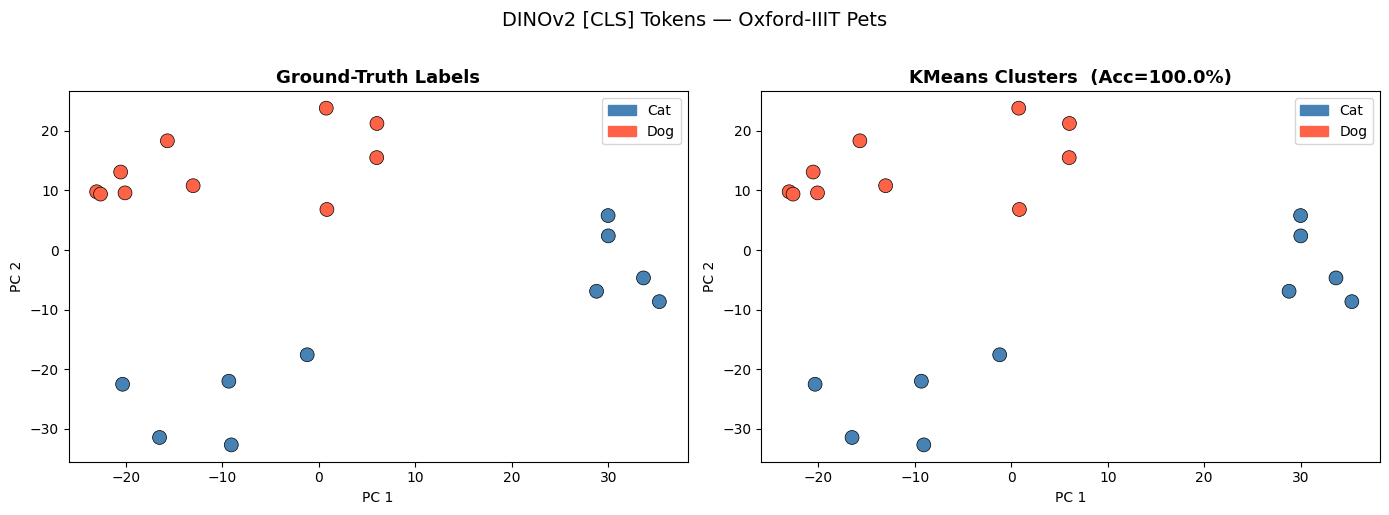


Plot saved → exercise1_clusters.png


In [15]:
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=SEED)
embs2 = pca.fit_transform(cls_tokens)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (labels, title) in zip(
    axes,
    [(ground_truths, "Ground-Truth Labels"),
     (aligned_labels, f"KMeans Clusters  (Acc={accuracy*100:.1f}%)")],
):
    colors = ["steelblue" if l == 0 else "tomato" for l in labels]
    ax.scatter(embs2[:, 0], embs2[:, 1], c=colors, s=100, edgecolors="k", linewidths=0.5)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")

    patches = [
        mpatches.Patch(color="steelblue", label="Cat"),
        mpatches.Patch(color="tomato",    label="Dog"),
    ]
    ax.legend(handles=patches, loc="upper right")

plt.suptitle("DINOv2 [CLS] Tokens — Oxford-IIIT Pets", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("exercise1_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → exercise1_clusters.png")

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [ ]:
# Provide your solution here

In [16]:
pip install transformers torch Pillow requests


  Using cached huggingface_hub-1.14.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 1.2 MB/s  0:00:09 eta 0:00:01m
Using cached huggingface_hub-1.14.0-py3-none-any.whl (661 kB)
Using cached hf_x

In [17]:
import requests
from PIL import Image
from io import BytesIO

from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch

/opt/anaconda3/envs/cv_lab/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# MODEL & PROCESSOR

In [18]:
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

print(f"Loading model: {MODEL_ID} …")
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModelForImageClassification.from_pretrained(MODEL_ID)
model.eval()
print("  Model loaded ✓\n")

Loading model: facebook/dinov2-small-imagenet1k-1-layer …


Loading weights: 100%|██████████| 225/225 [00:00<00:00, 11721.32it/s]

  Model loaded ✓



# FETCH AN IMAGE FROM THE WEB

In [21]:
IMAGE_URL = "https://images.dog.ceo/breeds/retriever-golden/n02099601_3004.jpg"
 
print(f"Fetching image from:\n  {IMAGE_URL}\n")
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(IMAGE_URL, headers=headers, timeout=15)
response.raise_for_status()
image = Image.open(BytesIO(response.content)).convert("RGB")
image.save("input_image.jpg")
print("  Image saved → input_image.jpg")

Fetching image from:
  https://images.dog.ceo/breeds/retriever-golden/n02099601_3004.jpg

  Image saved → input_image.jpg


# PRE-PROCESS

In [22]:
# AutoImageProcessor handles resize, centre-crop, normalise (ImageNet stats)
inputs = processor(images=image, return_tensors="pt")   # pixel_values: (1,3,H,W)

# INFERENCE

In [23]:
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits            # raw scores, shape (1, 1000)

# TOP-5 PREDICTIONS

In [24]:
probs        = torch.softmax(logits, dim=-1)[0]     # (1000,)
top5_probs, top5_ids = torch.topk(probs, k=5)

id2label = model.config.id2label   # dict mapping int → human-readable label

print("=" * 55)
print("  TOP-5 ImageNet-1k PREDICTIONS")
print("=" * 55)
print(f"  {'Rank':<6} {'Label':<35} {'Confidence':>10}")
print("-" * 55)
for rank, (prob, idx) in enumerate(zip(top5_probs, top5_ids), start=1):
    label = id2label[idx.item()]
    print(f"  {rank:<6} {label:<35} {prob.item()*100:>9.2f}%")
print("=" * 55)

top1_label = id2label[top5_ids[0].item()]
top1_conf  = top5_probs[0].item() * 100
print(f"\nPredicted class : {top1_label}")
print(f"Confidence: {top1_conf:.2f}%")

  TOP-5 ImageNet-1k PREDICTIONS
  Rank   Label                               Confidence
-------------------------------------------------------
  1      golden retriever                        97.41%
  2      Labrador retriever                       0.37%
  3      English setter                           0.34%
  4      otterhound, otter hound                  0.31%
  5      tennis ball                              0.22%

Predicted class : golden retriever
Confidence: 97.41%


# OPTIONAL — VISUALISE

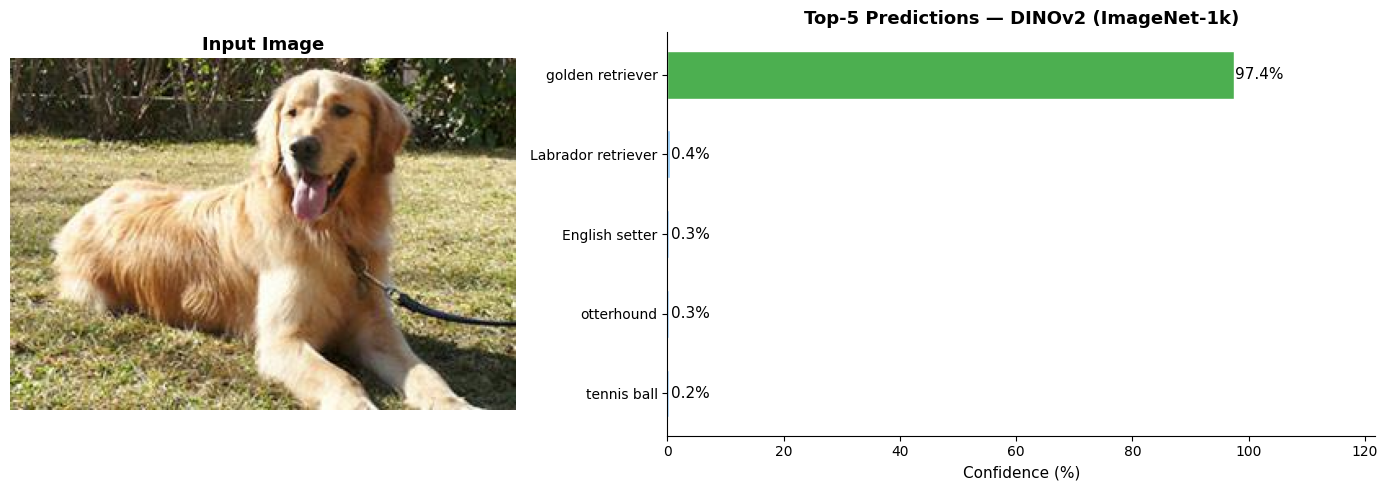


Plot saved → exercise2_predictions.png


In [26]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    labels = [id2label[i.item()].split(",")[0] for i in top5_ids]
    values = [p.item() * 100 for p in top5_probs]
    colors = ["#4CAF50" if r == 0 else "#90CAF9" for r in range(5)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             gridspec_kw={"width_ratios": [1, 1.4]})

    # Left: input image
    axes[0].imshow(image)
    axes[0].axis("off")
    axes[0].set_title("Input Image", fontsize=13, fontweight="bold")

    # Right: bar chart of top-5 probabilities
    bars = axes[1].barh(labels[::-1], values[::-1], color=colors[::-1],
                        edgecolor="white", height=0.6)
    for bar, val in zip(bars, values[::-1]):
        axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", fontsize=11)

    axes[1].set_xlim(0, max(values) * 1.25)
    axes[1].set_xlabel("Confidence (%)", fontsize=11)
    axes[1].set_title("Top-5 Predictions — DINOv2 (ImageNet-1k)", fontsize=13,
                       fontweight="bold")
    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("exercise2_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nPlot saved → exercise2_predictions.png")
except ImportError:
    print("\n(matplotlib not found — skipping visualisation)")